# jeanie basics

`jeanie` solves the isothermal Jeans model for an SIDM halo matched onto a CDM
outer halo at radius $r_1$ — the model of
[arXiv:2511.10765](https://arxiv.org/abs/2511.10765) — by a reduced numerical
route rather than the package's 402-dimensional relaxation.

**Four questions, in order:**

| § | Question | Short answer |
|:--|:--|:--|
| **1** | Does it agree with `jeans`? | yes, to a few parts in $10^{4}$ |
| **2** | Does the *whole profile* agree, not just the two solved numbers? | yes, below $10^{-3}$ everywhere inside $r_1$ |
| **3** | Why is it faster? | it is a smaller problem, not a faster language |
| **4** | Can I hand the result to an orbit integrator? | yes — galpy, agama or galax, in one call |

Every section states its conclusion first, in bold, then shows the work.

Companion notebooks: **`jeanie_differentiable.ipynb`** for gradients, ensembles
and existence; **`jeanie_export_potentials.ipynb`** for the export routes in
full detail.

> Run `pip install -e .` from the repository root first, so that `jeans` and
> `jeanie` are importable. Section 4 additionally needs
> `pip install -e ".[export]"`.

## Setup — one Milky-Way-like host

A $10^{12}\,M_\odot$ NFW halo with a Miyamoto–Nagai disc, matched at
$r_1 = 12$ kpc. Every number in this notebook comes from this one host.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import jeans                               # the upstream package: the reference
from jeans.classes import CDM_profile
from jeanie.outer import boundary_data
from jeanie.solver import solve_spherical

GN = 4.302e-6                              # kpc (km/s)^2 / Msun

# --- the host -------------------------------------------------------------
r1, M200, c = 12.0, 1e12, 10.0             # matching radius [kpc], halo mass [Msun], concentration
Md, a_d, b_d = 6e10, 3.0, 0.28             # disc mass [Msun], scale length and height [kpc]


def Phi_b(r, th):
    """Miyamoto-Nagai disc potential at spherical coordinates (r, theta)."""
    R2 = r ** 2 * np.sin(th) ** 2
    zb = a_d + np.sqrt(b_d ** 2 + r ** 2 * np.cos(th) ** 2)
    return -GN * Md / np.sqrt(R2 + zb ** 2)

## 1. The solve

**Both codes land on the same $(r_0, \sigma_0)$, to a few parts in $10^{4}$.**

`jeans.spherical` relaxes the full profile on a grid. `jeanie` reduces the same
equations to a two-parameter root-find on fixed RK4 nodes and inverts it by
bracketing.

In [2]:
# numba compiles on the first call, so warm it: otherwise the timing below is
# of the compiler, not of the solve
solve_spherical(r1, 1e6, 1e10, Phi_b=Phi_b)

t0 = time.perf_counter()
pkg = jeans.spherical(r1, M200, c, Phi_b=Phi_b)
t_pkg = time.perf_counter() - t0

# jeanie takes the CDM boundary values at r1, not (M200, c) directly
halo = CDM_profile(M200, c, q0=1.0, Phi_b=Phi_b)
rho1, M1, _ = boundary_data(halo, r1, L_list=(0,))

t0 = time.perf_counter()
fast = solve_spherical(r1, rho1, M1, Phi_b=Phi_b, trajectory=True)
t_fast = time.perf_counter() - t0

In [3]:
pd.DataFrame(
    {
        "jeans (reference)": [f"{pkg.inner.r0:.6f}", f"{pkg.inner.sigma0:.4f}",
                              f"{t_pkg:.2f}"],
        "jeanie":            [f"{fast.r0:.6f}", f"{fast.sigma0:.4f}",
                              f"{t_fast:.3f}"],
        "difference":        [f"{abs(fast.r0 / pkg.inner.r0 - 1):.1e}",
                              f"{abs(fast.sigma0 / pkg.inner.sigma0 - 1):.1e}",
                              "see section 3"],
    },
    index=["core radius r0 [kpc]",
           "dispersion sigma0 [km/s]",
           "wall time, one call [s]"],
)

,jeans (reference),jeanie,difference
core radius r0 [kpc],1.750342,1.750607,1.5e-04
dispersion sigma0 [km/s],156.5569,156.5550,1.3e-05
"wall time, one call [s]",1.82,0.016,see section 3


## 2. The density profile

**The two profiles lie on top of each other, with a residual below $10^{-3}$
across the inner halo.**

Agreeing on $(r_0, \sigma_0)$ is weaker than it looks — they are two numbers,
and two numbers can agree while the profile between them does not. The residual
below is set by the reduced solver's fixed step count, not by any difference in
the physics.

In [4]:
r = np.logspace(-1.3, 1.07, 120)
r = r[r < r1]

rho_pkg = np.array([float(pkg.rho_sph_avg(x)) for x in r])
rho_fast = np.array([float(fast.rho(float(x))) for x in r])
residual = rho_fast / rho_pkg - 1.0

worst relative difference: 9.30e-04


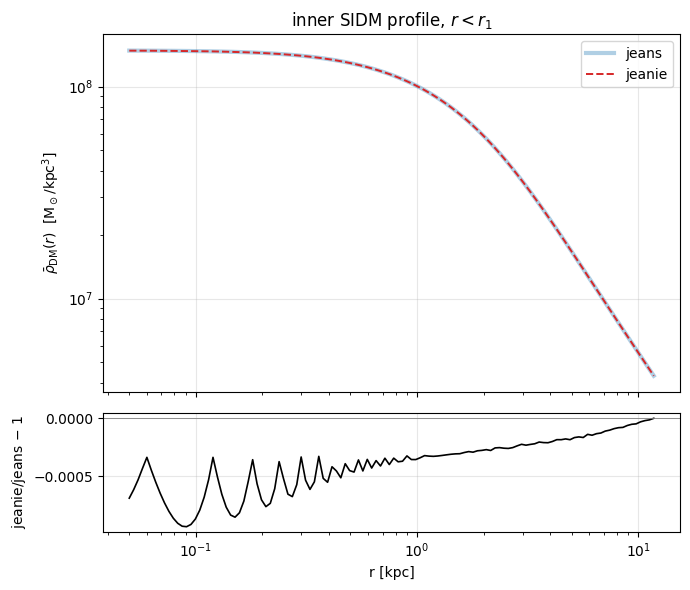

In [5]:
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True,
                        gridspec_kw={"height_ratios": [3, 1]})

axs[0].loglog(r, rho_pkg, lw=3, alpha=0.35, c="C0", label="jeans")
axs[0].loglog(r, rho_fast, lw=1.4, ls="--", c="C3", label="jeanie")
axs[0].set_ylabel(r"$\bar\rho_{\rm DM}(r)$  [M$_\odot$/kpc$^3$]")
axs[0].set_title(r"inner SIDM profile, $r < r_1$")
axs[0].legend()

axs[1].semilogx(r, residual, c="k", lw=1.2)
axs[1].axhline(0, c="grey", lw=0.6)
axs[1].set_xlabel("r [kpc]")
axs[1].set_ylabel("jeanie/jeans $-$ 1")

for ax in axs:
    ax.grid(alpha=0.3)
fig.tight_layout()

print(f"worst relative difference: {np.max(np.abs(residual)):.2e}")

## 3. Why it is faster

**A smaller problem, not a faster language.**

`jeans` evaluates its angular integrals with adaptive quadrature and relaxes
402 unknowns. `jeanie` uses fixed Gauss–Legendre nodes and solves for two.

Two `jeanie` routes are timed below.

The default **bracketed** solve inverts the problem by a monotone bracketed
search, so it cannot reach another branch of a multi-valued problem — and it
is also the cheaper of the two. The **continuation** route (`method="ramp"`)
is kept for comparison, and is timed here with its branch certificate switched
off (`verify=False`), so this is its cheapest form; it still loses. It also
cannot cover $R > R_{\rm MAX}$ at all, because its first stage is the
baryon-free problem, which has no solution there.

See `jeanie_differentiable.ipynb`, §4, for what those branches are.

In [6]:
reps = 5
routes = {
    "jeanie, bracketed (default)":
        lambda: solve_spherical(r1, rho1, M1, Phi_b=Phi_b),
    "jeanie, continuation":
        lambda: solve_spherical(r1, rho1, M1, Phi_b=Phi_b,
                                method="ramp", verify=False),
}

timings = {}
for name, fn in routes.items():
    fn()                                   # warm numba for this code path
    t0 = time.perf_counter()
    for _ in range(reps):
        fn()
    timings[name] = (time.perf_counter() - t0) / reps * 1e3

timings["jeans.spherical"] = t_pkg * 1e3   # measured once, above

pd.DataFrame(
    {"per solve [ms]": [f"{v:,.1f}" for v in timings.values()],
     "vs fastest": [f"{v / min(timings.values()):.0f}x" for v in timings.values()]},
    index=list(timings),
)

,per solve [ms],vs fastest
"jeanie, bracketed (default)",12.4,1x
"jeanie, continuation",31.1,3x
jeans.spherical,"1,817.1",146x


## 4. Handing the halo to an orbit integrator

**A solved halo exports to galpy, agama or galax in one call.**

`jeanie.export` turns the solution into `rho(R, z)`, `M(<r)`, `g_r(r)` and
`Phi(r)`, and does each library's unit conversion in one place — which is worth
having, because getting those wrong is *silent*: a mis-scaled potential still
integrates orbits, it just integrates the wrong ones.

Three things decide which route you want:

- **Shape.** Inside $r_1$ the disc flattens the halo, with a gradient in
  radius — measured in `jeanie_export_potentials.ipynb`, §2. Any export that
  reduces the halo to a function of $r$ alone throws that away.
- **Baryons.** The exported callables are *dark matter only*; `baryons=True`
  (the default) adds the disc back, which is what an orbit needs.
- **Differentiability.** Only the galax route keeps
  $\partial(\text{orbit})/\partial(\text{halo parameters})$.

| route | keeps the shape | differentiable | notes |
|:--|:--|:--|:--|
| `to_galpy(kind="multipole")` | yes | no | the default; galpy ≥ 1.12, C-backed orbits |
| `to_galpy(kind="multipole-ref")` | yes | no | jeanie's own expansion; works on galpy 1.11 |
| `to_galpy(kind="spherical")` | **no** | no | cheapest; monopole only |
| `to_agama` | yes | no | C++, fast; sets agama's global units |
| `to_galax` | monopole only | **yes** | the only route to `d(orbit)/d(params)` |
| `callables` | — | yes | wrap it into your own framework |

**`jeanie_export_potentials.ipynb` works through all of this** — the accuracy of
each expansion, the unit traps, and why `G` differs between libraries. What
follows is just the one-call version.

In [7]:
from jeanie.export import callables, to_galpy, to_agama, to_galax

# the same host, as the parameter vector the exporters take
params = np.array([M200, c, r1, Md, a_d, b_d])

fns = callables(params)        # framework-agnostic: rho(R,z), M(<r), g(r), Phi(r)

pots, build_time = {}, {}
for name, fn in [("galpy", to_galpy), ("agama", to_agama), ("galax", to_galax)]:
    t0 = time.perf_counter()
    pots[name] = fn(params)                      # baryons=True is the default
    build_time[name] = time.perf_counter() - t0

print("callables():", ", ".join(fns))
for name, t in build_time.items():
    print(f"  {name:6s} built in {t:5.1f} s")

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


callables(): rho, M, g, Phi
  galpy  built in   6.6 s
  agama  built in   4.5 s
  galax  built in   2.7 s


### The same rotation curve out of each one

The quickest check that an export is sane. galpy and agama both keep the
flattening and should agree; the dark-matter-only monopole shows how much of
the curve is the disc.

In [8]:
ro, vo = 8.0, 220.0                      # galpy's internal length and velocity units
F0 = vo ** 2 / ro

import galpy.potential as gpot

Rc = np.geomspace(1.0, 60.0, 40)

vc_galpy = np.array([
    np.sqrt(-float(gpot.evaluateRforces(pots["galpy"], x / ro, 0.0,
                                        use_physical=False)) * F0 * x)
    for x in Rc])

X = np.column_stack([Rc, np.zeros_like(Rc), np.zeros_like(Rc)])
vc_agama = np.sqrt(-np.asarray(pots["agama"].force(X))[:, 0] * Rc)

# jeanie's own radial acceleration: dark matter only, and spherically averaged
vc_dm = np.array([np.sqrt(-float(fns["g"](x)) * x) for x in Rc])

galpy vs agama:  median 1.1e-04   worst 5.6e-04
CODATA/jeanie G - 1 = -2.5e-04  <- the floor: agama applies CODATA G
   to jeanie's densities. The rest is the two expansions differing from each other.


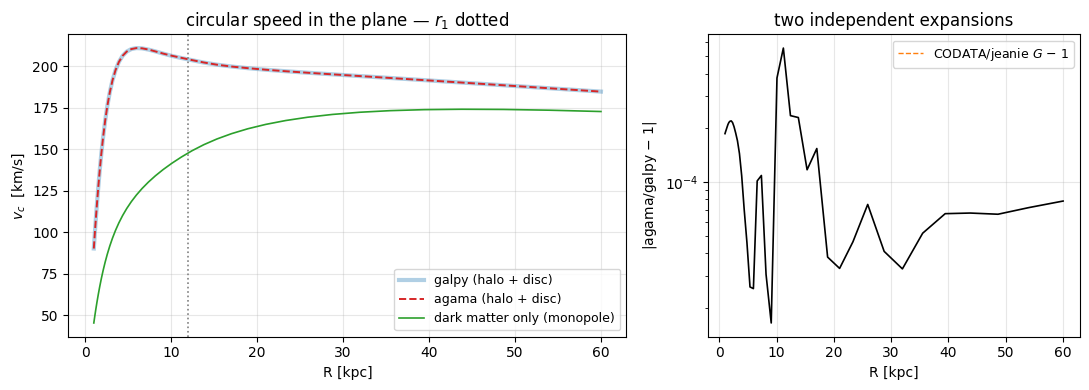

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4),
                       gridspec_kw={"width_ratios": [3, 2]})

ax[0].plot(Rc, vc_galpy, lw=3, alpha=0.35, c="C0", label="galpy (halo + disc)")
ax[0].plot(Rc, vc_agama, lw=1.4, ls="--", c="C3", label="agama (halo + disc)")
ax[0].plot(Rc, vc_dm, lw=1.2, c="C2", label="dark matter only (monopole)")
ax[0].axvline(r1, c="grey", ls=":", lw=1.2)
ax[0].set(xlabel="R [kpc]", ylabel=r"$v_c$  [km/s]",
          title=r"circular speed in the plane — $r_1$ dotted")
ax[0].legend(fontsize=9)

ax[1].semilogy(Rc, np.abs(vc_agama / vc_galpy - 1), c="k", lw=1.2)
ax[1].axhline(4.30091727e-6 / GN - 1, c="C1", ls="--", lw=1,
              label="CODATA/jeanie $G$ $-$ 1")
ax[1].set(xlabel="R [kpc]", ylabel="|agama/galpy $-$ 1|",
          title="two independent expansions")
ax[1].legend(fontsize=9)

for a_ in ax:
    a_.grid(alpha=0.3)
fig.tight_layout()

d = np.abs(vc_agama / vc_galpy - 1)
print(f"galpy vs agama:  median {np.median(d):.1e}   worst {d.max():.1e}")
print(f"CODATA/jeanie G - 1 = {4.30091727e-6 / GN - 1:.1e}  <- the floor: agama "
      f"applies CODATA G\n   to jeanie's densities. The rest is the two "
      f"expansions differing from each other.")

### An orbit, and a gradient

galpy's multipole is C-backed, so the orbit integrates in C even though the
density that built it is a JAX function in Python. galax gives up the
flattening but keeps the derivative chain intact.

In [10]:
from galpy.orbit import Orbit

o = Orbit([12.0 / ro, 0.0, 180.0 / vo, 1.5 / ro, 20.0 / vo, 0.0], ro=ro, vo=vo)
ts = np.linspace(0.0, 3.0, 2000) * 1.0227       # 3 Gyr, in galpy time units

t0 = time.perf_counter()
o.integrate(ts, pots["galpy"])
dt = time.perf_counter() - t0

E = o.E(ts, pot=pots["galpy"], use_physical=False)
print(f"3 Gyr in 2000 steps: {dt:.2f} s, dE/|E| = {np.ptp(E) / abs(np.mean(E)):.1e}")

3 Gyr in 2000 steps: 0.04 s, dE/|E| = 7.1e-14


In [11]:
import jax
import jax.numpy as jnp


def phi_at_point(p):
    """Potential at (R, z) = (20, 5) kpc, as a function of the halo parameters."""
    return to_galax(p).potential(jnp.array([20.0, 0.0, 5.0]), 0.0)


phi0 = float(phi_at_point(jnp.asarray(params)))
grad = np.asarray(jax.grad(phi_at_point)(jnp.asarray(params)))

# as a log derivative: the fractional change in Phi per e-fold of each
# parameter. The raw gradient is ~1e-13 in galax units and reads as zero.
pd.DataFrame({"dln|Phi| / dln p  at (R,z) = (20, 5) kpc":
              [f"{g * float(x) / phi0:+.3e}" for g, x in zip(grad, params)]},
             index=["M200", "c", "r1", "Md", "a", "b"])

,"dln|Phi| / dln p at (R,z) = (20, 5) kpc"
M200,+6.621e-01
c,+1.780e-01
r1,+4.310e-02
Md,+1.147e-01
a,-5.938e-03
b,-3.099e-05


`Md`, `a` and `b` are non-zero, which is the check that the baryons really are
in the exported potential. Exactly zero on those three means `baryons=False`
slipped in somewhere — the most common way to get a wrong answer here, because
the orbit still integrates perfectly happily without them.

## What to take away

1. `jeanie` reproduces `jeans` on this host to a few parts in $10^{4}$ in
   $(r_0, \sigma_0)$ and below $10^{-3}$ in the profile.
2. The speedup comes from solving for 2 unknowns instead of 402, so it survives
   being embedded in a sampler.
3. The default solve brackets, so it cannot silently return the wrong branch.
4. One call hands the result to galpy, agama or galax, with the unit and `G`
   conversions done in one place.

**Next:** `jeanie_differentiable.ipynb` (gradients, `vmap` ensembles, the
existence criterion) and `jeanie_export_potentials.ipynb` (how accurate each
export actually is, and where each one fails).